# PEDA — Configuration-Conditioned GNN + Parameter-Efficient Domain Adaptation (MEMORY-SAFE)

**Source of truth:** `preprocessing_fixed_final (1)(1).ipynb` outputs in `/content/drive/MyDrive/PEDA_Processed`.

This notebook uses the **final compact file format**:
- `data_c2_raw.pt`
- `data_c20_raw.pt`
- `n14_base_x.pt`
- `n14_edge_index.pt`
- `n14_configs_norm.npy`
- `n14_labels_raw.npy`
- all saved scaler/stat files

Key design correction: the old GNN predicted all configurations from one identical graph embedding and therefore ignored configuration identity. This notebook explicitly separates **topology features** from **configuration features**, encodes both, and predicts one RUDY value per configuration.

In [2]:
# CELL 1 — Environment, Drive, imports, reproducibility
!pip install torch-geometric -q

from google.colab import drive
drive.mount('/content/drive')

import os, random, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_dir = '/content/drive/MyDrive/PEDA_Processed'
print('PyTorch:', torch.__version__)
print('Device :', device)
if torch.cuda.is_available():
    print('GPU    :', torch.cuda.get_device_name(0))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cpu
Device : cpu


In [3]:
# CELL 2 — Strict required-file check
required = [
    'data_c2_raw.pt', 'data_c20_raw.pt',
    'n14_base_x.pt', 'n14_edge_index.pt', 'n14_configs_norm.npy', 'n14_labels_raw.npy',
    'scaler_mean.npy', 'scaler_std.npy',
    'config_mean.npy', 'config_std.npy',
    'n14_config_mean.npy', 'n14_config_std.npy',
    'label_c2_mean.npy', 'label_c2_std.npy',
    'label_c20_mean.npy', 'label_c20_std.npy',
    'label_n14_mean.npy', 'label_n14_std.npy',
]
missing = [f for f in required if not os.path.isfile(os.path.join(save_dir, f))]
if missing:
    raise FileNotFoundError('Missing required preprocessing outputs:\n' + '\n'.join(missing))
print('✓ All required preprocessing outputs are present.')


✓ All required preprocessing outputs are present.


In [4]:
# CELL 3 — Load final preprocessing outputs
data_c2  = torch.load(f'{save_dir}/data_c2_raw.pt',  weights_only=False)
data_c20 = torch.load(f'{save_dir}/data_c20_raw.pt', weights_only=False)

n14_base_x     = torch.load(f'{save_dir}/n14_base_x.pt', weights_only=False).float()
n14_edge_index = torch.load(f'{save_dir}/n14_edge_index.pt', weights_only=False).long()
n14_configs    = np.load(f'{save_dir}/n14_configs_norm.npy').astype(np.float32)
n14_labels     = np.load(f'{save_dir}/n14_labels_raw.npy').astype(np.float32)

scaler_mean = np.load(f'{save_dir}/scaler_mean.npy').astype(np.float32)
scaler_std  = np.load(f'{save_dir}/scaler_std.npy').astype(np.float32)
config_mean = np.load(f'{save_dir}/config_mean.npy').astype(np.float32)
config_std  = np.load(f'{save_dir}/config_std.npy').astype(np.float32)
n14_config_mean = np.load(f'{save_dir}/n14_config_mean.npy').astype(np.float32)
n14_config_std  = np.load(f'{save_dir}/n14_config_std.npy').astype(np.float32)

label_stats = {
    'c2':  (float(np.load(f'{save_dir}/label_c2_mean.npy')),  float(np.load(f'{save_dir}/label_c2_std.npy'))),
    'c20': (float(np.load(f'{save_dir}/label_c20_mean.npy')), float(np.load(f'{save_dir}/label_c20_std.npy'))),
    'n14': (float(np.load(f'{save_dir}/label_n14_mean.npy')), float(np.load(f'{save_dir}/label_n14_std.npy'))),
}

print(f'C2  : {len(data_c2)} configs, x={tuple(data_c2[0].x.shape)}')
print(f'C20 : {len(data_c20)} configs, x={tuple(data_c20[0].x.shape)}')
print(f'N14 : {len(n14_labels)} configs, base_x={tuple(n14_base_x.shape)}, cfg_dim={n14_configs.shape[1]}')
print('Label stats:', label_stats)


C2  : 264 configs, x=(42102, 6)
C20 : 271 configs, x=(41405, 6)
N14 : 3441 configs, base_x=(34983, 2), cfg_dim=5
Label stats: {'c2': (0.0018383599817752838, 0.0003810771449934691), 'c20': (0.0019982291851192713, 0.0007586818537674844), 'n14': (0.0049184164963662624, 0.0008739899494685233)}


In [5]:
# CELL 4 — Data integrity checks and configuration-aware representation

def check_list(name, data_list, expected_cfg_dim):
    assert len(data_list) > 0, f'{name} is empty'
    n, d = data_list[0].x.shape
    assert d == 2 + expected_cfg_dim, f'{name}: expected {2+expected_cfg_dim} features, got {d}'
    ys = []
    for i, dta in enumerate(data_list):
        assert dta.x.ndim == 2 and dta.x.shape[1] == d
        assert dta.edge_index.ndim == 2 and dta.edge_index.shape[0] == 2
        assert dta.edge_index.min().item() >= 0 and dta.edge_index.max().item() < dta.x.shape[0]
        assert dta.y.numel() == 1
        assert torch.isfinite(dta.x).all() and torch.isfinite(dta.y).all()
        # Config is broadcast to every node; verify that invariant.
        assert torch.allclose(dta.x[:, 2:], dta.x[0:1, 2:].expand_as(dta.x[:, 2:]))
        ys.append(float(dta.y.item()))
    print(f'✓ {name}: {len(data_list)} configs | nodes={n} | features={d} | y=[{min(ys):.6g}, {max(ys):.6g}]')

check_list('C2', data_c2, 4)
check_list('C20', data_c20, 4)
assert n14_base_x.shape[1] == 2
assert n14_configs.shape[0] == len(n14_labels)
assert n14_configs.shape[1] == 5
assert n14_edge_index.min().item() >= 0 and n14_edge_index.max().item() < n14_base_x.shape[0]
assert np.isfinite(n14_configs).all() and np.isfinite(n14_labels).all()
assert torch.isfinite(n14_base_x).all()
print(f'✓ N14: {len(n14_labels)} configs | nodes={n14_base_x.shape[0]} | base features=2 | config features=5')

# The preprocessing file stores C2/C20 as [degree, avg_fanout, u, m, p, f].
# N14 is stored compactly as base_x=[2 features] plus cfg=[5 features].


✓ C2: 264 configs | nodes=42102 | features=6 | y=[0.00125871, 0.00237738]
✓ C20: 271 configs | nodes=41405 | features=6 | y=[0.0013148, 0.00669342]
✓ N14: 3441 configs | nodes=34983 | base features=2 | config features=5


## Model design

The graph encoder sees only the two topology features. A separate configuration encoder maps the 4-D N28 or 5-D N14 configuration into the same latent dimension. The final predictor combines:

`graph embedding + configuration embedding → MLP → RUDY`

This avoids the old mistake where all configurations shared one identical prediction input. It also makes the N28→N14 transfer dimension-safe.

In [6]:
# CELL 5 — Dataset helpers
def list_to_tensors(data_list):
    # Since every Data object is one configuration, keep each graph separate.
    base_x = [d.x[:, :2].float() for d in data_list]
    cfg    = [d.x[0, 2:].float() for d in data_list]
    y      = torch.tensor([float(d.y.item()) for d in data_list], dtype=torch.float32)
    edge   = [d.edge_index.long() for d in data_list]
    return base_x, cfg, y, edge

c2_base, c2_cfg, c2_y_raw, c2_edges = list_to_tensors(data_c2)
c20_base, c20_cfg, c20_y_raw, c20_edges = list_to_tensors(data_c20)

n14_base = n14_base_x.float()
n14_cfg = torch.from_numpy(n14_configs).float()
n14_y_raw = torch.from_numpy(n14_labels).float()

assert c2_cfg[0].numel() == 4 and c20_cfg[0].numel() == 4 and n14_cfg.shape[1] == 5
print('✓ Dataset helpers ready.')


✓ Dataset helpers ready.


In [7]:
# CELL 6 — Deterministic C2 train/validation split
n_c2 = len(c2_y_raw)
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_c2, generator=g)
n_train = int(0.8 * n_c2)
train_idx = perm[:n_train]
val_idx = perm[n_train:]
print(f'C2 total={n_c2} | train={len(train_idx)} | val={len(val_idx)}')


C2 total=264 | train=211 | val=53


In [8]:
# CELL 7 — Configuration-conditioned GNN
class ConfigConditionedGNN(nn.Module):
    def __init__(self, base_in=2, cfg_dims=(4,5), hidden=64, graph_dim=32, cfg_dim=16, dropout=0.10):
        super().__init__()
        self.hidden = hidden
        self.graph_dim = graph_dim
        self.cfg_dim = cfg_dim
        self.dropout = dropout

        self.conv1 = GCNConv(base_in, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, graph_dim)

        # Separate configuration encoders for N28 (4-D) and N14 (5-D).
        # Both produce the same cfg_dim, enabling transfer.
        self.cfg_encoder_n28 = nn.Sequential(
            nn.Linear(cfg_dims[0], 32), nn.ReLU(), nn.Linear(32, cfg_dim), nn.ReLU()
        )
        self.cfg_encoder_n14 = nn.Sequential(
            nn.Linear(cfg_dims[1], 32), nn.ReLU(), nn.Linear(32, cfg_dim), nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(graph_dim + cfg_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def encode_graph(self, x_base, edge_index):
        h = F.relu(self.conv1(x_base, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv3(h, edge_index)
        return h.mean(dim=0)

    def encode_config(self, cfg, domain):
        if domain == 'n28':
            return self.cfg_encoder_n28(cfg)
        if domain == 'n14':
            return self.cfg_encoder_n14(cfg)
        raise ValueError("domain must be 'n28' or 'n14'")

    def forward_one(self, x_base, edge_index, cfg, domain):
        g = self.encode_graph(x_base, edge_index)
        c = self.encode_config(cfg, domain)
        return self.head(torch.cat([g, c], dim=0)).squeeze(-1)

    def predict_list(self, base_list, cfg_list, edge_list, domain):
        return torch.stack([self.forward_one(x, e, c, domain) for x, c, e in zip(base_list, cfg_list, edge_list)])

    def predict_n14(self, base_x, edge_index, cfg_matrix):
        # N14 base graph is fixed; build one prediction per configuration without duplicating the graph in RAM.
        g = self.encode_graph(base_x, edge_index)
        c = self.cfg_encoder_n14(cfg_matrix)
        g_batch = g.unsqueeze(0).expand(cfg_matrix.shape[0], -1)
        return self.head(torch.cat([g_batch, c], dim=1)).squeeze(-1)

model = ConfigConditionedGNN().to(device)
print(model)
print('Total parameters:', sum(p.numel() for p in model.parameters()))

# Move only compact tensors / C2-C20 lists to device lazily in the training loop.


ConfigConditionedGNN(
  (conv1): GCNConv(2, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 32)
  (cfg_encoder_n28): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (cfg_encoder_n14): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 13089


In [9]:
# CELL 8 — Shared-graph, memory-safe helpers
# IMPORTANT: C2/C20 contain the SAME circuit topology for every configuration.
# Only the configuration vector changes. Therefore the expensive GCN graph
# embedding is computed ONCE per epoch/evaluation call and reused for all configs.
# This avoids both extremes: whole-dataset CUDA OOM and one-GCN-pass-per-config slowness.

def to_device_graph(base_x, edge_index):
    return (base_x.to(device, non_blocking=True),
            edge_index.to(device, non_blocking=True))

c2_mean, c2_std = label_stats['c2']
c20_mean, c20_std = label_stats['c20']
n14_mean, n14_std = label_stats['n14']

def raw_to_c2_norm(y):
    return (y - c2_mean) / max(c2_std, 1e-12)

def c2_norm_to_raw(y):
    return y * c2_std + c2_mean

def metrics_raw(pred_raw, true_raw):
    pred_raw = pred_raw.detach()
    true_raw = true_raw.detach()
    err = pred_raw - true_raw
    mse = torch.mean(err**2).item()
    mae = torch.mean(torch.abs(err)).item()
    rmse = math.sqrt(mse)
    vx = pred_raw - pred_raw.mean()
    vy = true_raw - true_raw.mean()
    pcc = (torch.sum(vx*vy) / (torch.linalg.vector_norm(vx)*torch.linalg.vector_norm(vy) + 1e-12)).item()
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'Pearson': pcc}

def print_metrics(name, m):
    print(f"{name:<28} MSE={m['MSE']:.8g} | MAE={m['MAE']:.8g} | RMSE={m['RMSE']:.8g} | Pearson={m['Pearson']:.6f}")

def _indices_list(indices, n):
    if indices is None:
        return list(range(n))
    return indices.tolist() if torch.is_tensor(indices) else list(indices)

def predict_shared_graph(model, base_x, cfg_list, edge_index, domain, indices=None):
    """Fast prediction for configurations sharing one circuit graph."""
    model.eval()
    idx = _indices_list(indices, len(cfg_list))
    x, e = to_device_graph(base_x, edge_index)
    cfg_batch = torch.stack([cfg_list[i] for i in idx], dim=0).to(device, non_blocking=True)
    with torch.no_grad():
        g = model.encode_graph(x, e)
        c = model.encode_config(cfg_batch, domain)
        g_batch = g.unsqueeze(0).expand(len(idx), -1)
        pred = model.head(torch.cat([g_batch, c], dim=1)).squeeze(-1)
    out = pred.detach().cpu()
    del x, e, cfg_batch, g, c, g_batch, pred
    return out

def train_shared_graph(model, base_x, cfg_list, edge_index, y_norm, train_indices, optimizer, loss_fn, max_grad_norm=5.0):
    """
    Exact full-batch mean-MSE training for one shared graph.
    One GCN forward + one backward per epoch; only the tiny config batch scales with N.
    """
    model.train()
    optimizer.zero_grad(set_to_none=True)
    idx = _indices_list(train_indices, len(cfg_list))

    x, e = to_device_graph(base_x, edge_index)
    cfg_batch = torch.stack([cfg_list[i] for i in idx], dim=0).to(device, non_blocking=True)
    y_batch = y_norm[idx].to(device, non_blocking=True)

    g = model.encode_graph(x, e)
    c = model.encode_config(cfg_batch, 'n28')
    g_batch = g.unsqueeze(0).expand(len(idx), -1)
    pred = model.head(torch.cat([g_batch, c], dim=1)).squeeze(-1)

    loss = loss_fn(pred, y_batch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
    optimizer.step()

    value = loss.item()
    del x, e, cfg_batch, y_batch, g, c, g_batch, pred, loss
    return value

def train_peda_shared_graph(peda_model, base_x, cfg_list, edge_index, y_norm, train_indices, optimizer, loss_fn, max_grad_norm=5.0):
    """Fast C20 PEDA training: one frozen GCN embedding, batched configs, one backward."""
    peda_model.train()
    optimizer.zero_grad(set_to_none=True)
    idx = _indices_list(train_indices, len(cfg_list))

    x, e = to_device_graph(base_x, edge_index)
    cfg_batch = torch.stack([cfg_list[i] for i in idx], dim=0).to(device, non_blocking=True)
    y_batch = y_norm[idx].to(device, non_blocking=True)

    with torch.no_grad():
        g = peda_model.base.encode_graph(x, e)
        c = peda_model.base.encode_config(cfg_batch, 'n28')

    g = peda_model.graph_adapter(g).unsqueeze(0).expand(len(idx), -1)
    c = peda_model.cfg_adapter(c)
    z = torch.cat([g, c], dim=1)
    z = F.relu(peda_model.base.head[0](z))
    z = peda_model.head_adapter(z)
    z = F.relu(peda_model.base.head[3](z))
    pred = peda_model.base.head[5](z).squeeze(-1)

    loss = loss_fn(pred, y_batch)
    trainable_params = [p for p in peda_model.parameters() if p.requires_grad]
    loss.backward()
    torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=max_grad_norm)
    optimizer.step()

    value = loss.item()
    del x, e, cfg_batch, y_batch, g, c, z, pred, loss
    return value

# Sanity check: preprocessing stores the same base graph for every N28 configuration.
def verify_shared_graph(data_list, name, checks=10):
    k = min(checks, len(data_list))
    same_x = all(torch.equal(data_list[0].x[:, :2], data_list[i].x[:, :2]) for i in range(1, k))
    same_e = all(torch.equal(data_list[0].edge_index, data_list[i].edge_index) for i in range(1, k))
    print(f'{name}: base_x identical={same_x} | edge_index identical={same_e} | checked={k}')
    assert same_x and same_e, f'{name} is not a shared-topology dataset; use graph mini-batching instead.'

verify_shared_graph(data_c2, 'C2', checks=len(data_c2))
verify_shared_graph(data_c20, 'C20', checks=len(data_c20))
print('✓ Shared-graph fast helpers ready.')


C2: base_x identical=True | edge_index identical=True | checked=264
C20: base_x identical=True | edge_index identical=True | checked=271
✓ Shared-graph fast helpers ready.


In [10]:
# CELL 9 — Base GNN training on C2 source (FAST + MEMORY-SAFE)
# C2 uses one fixed circuit graph with a different 4-D configuration per sample.
# The expensive 3-layer GCN is therefore evaluated ONCE per epoch.
# The 211 training configurations are processed together as a tiny [N,4] matrix.
# This removes the previous 211 full-GCN passes per epoch and avoids the 14.6-GiB OOM.

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=25
)
loss_fn = nn.MSELoss()
EPOCHS = 300
EARLY_STOPPING_PATIENCE = 40
best_val = float('inf')
epochs_without_improvement = 0
train_losses, val_losses = [], []

y_c2_norm = raw_to_c2_norm(c2_y_raw)

print(f'C2 training: {len(train_idx)} train configs | {len(val_idx)} validation configs')
print('Graph embedding: 1 GCN pass/epoch (shared across configurations)')

for epoch in range(1, EPOCHS + 1):
    train_loss = train_shared_graph(
        model, c2_base[0], c2_cfg, c2_edges[0],
        y_c2_norm, train_idx, optimizer, loss_fn, max_grad_norm=5.0
    )

    val_pred = predict_shared_graph(
        model, c2_base[0], c2_cfg, c2_edges[0], 'n28', indices=val_idx
    )
    val_true = y_c2_norm[val_idx].detach().cpu()
    val_loss = loss_fn(val_pred, val_true)
    val_value = val_loss.item()

    scheduler.step(val_value)
    train_losses.append(train_loss)
    val_losses.append(val_value)

    if val_value < best_val - 1e-10:
        best_val = val_value
        epochs_without_improvement = 0
        torch.save(model.state_dict(), f'{save_dir}/base_gnn_config_conditioned.pt')
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 25 == 0:
        print(
            f'Epoch {epoch:3d} | train={train_loss:.6f} | '
            f'val={val_value:.6f} | lr={optimizer.param_groups[0]["lr"]:.2e}'
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping at epoch {epoch} (no validation improvement for {EARLY_STOPPING_PATIENCE} epochs).')
        break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

model.load_state_dict(
    torch.load(
        f'{save_dir}/base_gnn_config_conditioned.pt',
        map_location=device,
        weights_only=True
    )
)
print(f'✓ Best C2 validation loss: {best_val:.6f}')
print('✓ Saved:', f'{save_dir}/base_gnn_config_conditioned.pt')

# ------------------------------------------------------------
# FIX: permanently freeze the trained C2 source model.
# `model` is the pretrained backbone every PEDA adapter wraps.
# Freezing + eval() here, once, guarantees it can never be
# accidentally mutated by any later adaptation step.
# ------------------------------------------------------------
model.eval()
for p in model.parameters():
    p.requires_grad = False
print('\u2713 model permanently frozen after C2 training (requires_grad=False on all params).')



C2 training: 211 train configs | 53 validation configs
Graph embedding: 1 GCN pass/epoch (shared across configurations)
Epoch   1 | train=1.002669 | val=1.034993 | lr=1.00e-03
Epoch  25 | train=0.909213 | val=0.941149 | lr=1.00e-03
Epoch  50 | train=0.630487 | val=0.667790 | lr=1.00e-03
Epoch  75 | train=0.404159 | val=0.482275 | lr=1.00e-03
Epoch 100 | train=0.308632 | val=0.390510 | lr=1.00e-03
Epoch 125 | train=0.244445 | val=0.312363 | lr=1.00e-03
Epoch 150 | train=0.204157 | val=0.245486 | lr=1.00e-03
Epoch 175 | train=0.167065 | val=0.200387 | lr=1.00e-03
Epoch 200 | train=0.140951 | val=0.172065 | lr=1.00e-03
Epoch 225 | train=0.124900 | val=0.154362 | lr=1.00e-03
Epoch 250 | train=0.102087 | val=0.138295 | lr=1.00e-03
Epoch 275 | train=0.060242 | val=0.113003 | lr=1.00e-03
Epoch 300 | train=0.038444 | val=0.082653 | lr=1.00e-03
✓ Best C2 validation loss: 0.080679
✓ Saved: /content/drive/MyDrive/PEDA_Processed/base_gnn_config_conditioned.pt
✓ model permanently frozen after C2 tr

In [11]:
# CELL 10 — Baseline: before PEDA, all domains (FAST + MEMORY-SAFE)
model.eval()

pred_c2_norm = predict_shared_graph(model, c2_base[0], c2_cfg, c2_edges[0], 'n28')
pred_c20_norm = predict_shared_graph(model, c20_base[0], c20_cfg, c20_edges[0], 'n28')

with torch.no_grad():
    n14_base_d = n14_base_x.to(device)
    n14_edge_d = n14_edge_index.to(device)
    n14_cfg_d = torch.from_numpy(n14_configs).float().to(device)
    pred_n14_norm = model.predict_n14(n14_base_d, n14_edge_d, n14_cfg_d)
    del n14_base_d, n14_edge_d, n14_cfg_d

pred_c2_raw = c2_norm_to_raw(pred_c2_norm.to(device))
pred_c20_raw = c2_norm_to_raw(pred_c20_norm.to(device))
pred_n14_raw = c2_norm_to_raw(pred_n14_norm)

print('=== BEFORE PEDA ===')
print_metrics('C2 all', metrics_raw(pred_c2_raw, c2_y_raw.to(device)))
print_metrics('C2 validation', metrics_raw(pred_c2_raw[val_idx.to(device)], c2_y_raw[val_idx.to(device)].to(device)))
print_metrics('C20', metrics_raw(pred_c20_raw, c20_y_raw.to(device)))
print_metrics('N14', metrics_raw(pred_n14_raw, n14_y_raw.to(device)))


=== BEFORE PEDA ===
C2 all                       MSE=6.0150502e-09 | MAE=5.2938547e-05 | RMSE=7.7556755e-05 | Pearson=0.979146
C2 validation                MSE=1.171613e-08 | MAE=7.4365722e-05 | RMSE=0.00010824107 | Pearson=0.962323
C20                          MSE=6.8784215e-07 | MAE=0.00035087363 | RMSE=0.00082936249 | Pearson=0.090054
N14                          MSE=1.1773116e-05 | MAE=0.0033051644 | RMSE=0.0034311975 | Pearson=0.038250


## PEDA adaptation

The source-trained graph encoder, both configuration encoders, and prediction head are frozen. Only small residual adapters are trained on target-domain supervision.

For C20, adaptation uses an 80/20 configuration split. For N14, the compact representation is used directly; no giant duplicated N14 dataset is created.

In [12]:
# CELL 11 — Residual low-rank adapters
class LowRankAdapter(nn.Module):
    def __init__(self, dim, rank=4, scale=0.1):
        super().__init__()
        self.down = nn.Linear(dim, rank, bias=False)
        self.up = nn.Linear(rank, dim, bias=False)
        self.scale = scale
        nn.init.kaiming_uniform_(self.down.weight, a=math.sqrt(5))
        nn.init.zeros_(self.up.weight)

    def forward(self, x):
        return x + self.scale * self.up(F.relu(self.down(x)))

class PEDAWrapper(nn.Module):
    def __init__(self, base_model, rank=4):
        super().__init__()
        self.base = base_model
        self.graph_adapter = LowRankAdapter(base_model.graph_dim, rank=rank)
        self.cfg_adapter = LowRankAdapter(base_model.cfg_dim, rank=rank)
        self.head_adapter = LowRankAdapter(64, rank=rank)

        for p in self.base.parameters():
            p.requires_grad = False

    def forward_one(self, x_base, edge_index, cfg, domain):
        with torch.no_grad():
            g = self.base.encode_graph(x_base, edge_index)
            c = self.base.encode_config(cfg, domain)
        g = self.graph_adapter(g)
        c = self.cfg_adapter(c)
        z = torch.cat([g, c], dim=0)
        z = self.base.head[0](z)
        z = F.relu(z)
        z = self.head_adapter(z)
        z = self.base.head[3](z)
        z = F.relu(z)
        z = self.base.head[5](z)
        return z.squeeze(-1)

    def predict_list(self, base_list, cfg_list, edge_list, domain):
        return torch.stack([self.forward_one(x,e,c,domain) for x,c,e in zip(base_list,cfg_list,edge_list)])

    def predict_n14(self, base_x, edge_index, cfg_matrix):
        # Keep the graph encoder detached, but allow the N14-specific
        # configuration encoder to train during N14 adaptation. N14 has a
        # 5-D configuration space that was not present in C2.
        with torch.no_grad():
            g = self.base.encode_graph(base_x, edge_index)
        c = self.base.cfg_encoder_n14(cfg_matrix)
        g = self.graph_adapter(g).unsqueeze(0).expand(cfg_matrix.shape[0], -1)
        c = self.cfg_adapter(c)
        z = torch.cat([g, c], dim=1)
        z = F.relu(self.base.head[0](z))
        z = self.head_adapter(z)
        z = F.relu(self.base.head[3](z))
        z = self.base.head[5](z)
        return z.squeeze(-1)

# FIX: wrap a deep copy of `model`, not `model` itself.
# PEDAWrapper.__init__ does `self.base = base_model` -- a Python
# reference, not a copy. Wrapping `model` directly would make
# `peda.base` and `model` the SAME object in memory, so any
# future unfreezing/training touching `peda.base` would silently
# mutate `model` (the supposedly-frozen source backbone) too.
peda = PEDAWrapper(copy.deepcopy(model), rank=4).to(device)
trainable = sum(p.numel() for p in peda.parameters() if p.requires_grad)
total = sum(p.numel() for p in peda.parameters())
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Trainable fraction  : {100*trainable/total:.2f}%')


Total parameters    : 13,985
Trainable parameters: 896
Trainable fraction  : 6.41%


In [13]:
# CELL 12 — PEDA sanity check: zero-initialized adapters reproduce base model

peda.eval()
model.eval()

# Use the first 3 C2 configurations.
# The latest memory-safe notebook keeps C2 graph/config data on CPU
# and moves only the small test subset to the selected device.

test_base = [x.to(device) for x in c2_base[:3]]
test_cfg  = [c.to(device) for c in c2_cfg[:3]]
test_edges = [e.to(device) for e in c2_edges[:3]]

with torch.no_grad():
    base_c2 = model.predict_list(
        test_base,
        test_cfg,
        test_edges,
        'n28'
    )

    peda_c2 = peda.predict_list(
        test_base,
        test_cfg,
        test_edges,
        'n28'
    )

    max_diff = torch.max(torch.abs(base_c2 - peda_c2)).item()

print(f'Max absolute difference at initialization: {max_diff:.3e}')

assert max_diff < 1e-6, 'Adapter initialization is not identity.'

print('✓ PEDA starts as the frozen base model.')

Max absolute difference at initialization: 0.000e+00
✓ PEDA starts as the frozen base model.


In [14]:
# CELL 13 — C20 PEDA adaptation (80/20, FAST + MEMORY-SAFE)

n_c20 = len(c20_y_raw)

# ------------------------------------------------------------
# Deterministic 80/20 configuration split
# ------------------------------------------------------------
g = torch.Generator().manual_seed(SEED)
perm20 = torch.randperm(n_c20, generator=g)

n20_train = int(0.8 * n_c20)

c20_train_idx = perm20[:n20_train]
c20_val_idx = perm20[n20_train:]

print(
    f"C20 total={n_c20} | "
    f"train={len(c20_train_idx)} | "
    f"val={len(c20_val_idx)}"
)

# ------------------------------------------------------------
# PEDA-specific shared-graph prediction
#
# IMPORTANT:
# predict_shared_graph() is for ConfigConditionedGNN.
# PEDAWrapper does not expose encode_graph() directly;
# the frozen base model is accessed through peda.base.
# ------------------------------------------------------------
def predict_peda_shared_graph(
    peda_model,
    base_x,
    cfg_list,
    edge_index,
    domain,
    indices=None
):
    """
    Fast PEDA prediction when all configurations share
    the same circuit graph.

    Expensive GCN:
        computed ONCE

    Configurations:
        processed together as a small batch

    Returns:
        CPU tensor of predictions
    """

    peda_model.eval()

    idx = _indices_list(indices, len(cfg_list))

    # Move only the single shared graph to GPU.
    x, e = to_device_graph(base_x, edge_index)

    # Small configuration batch.
    cfg_batch = torch.stack(
        [cfg_list[i] for i in idx],
        dim=0
    ).to(device, non_blocking=True)

    with torch.no_grad():

        # Frozen base graph encoder — ONE GCN pass.
        g = peda_model.base.encode_graph(x, e)

        # Frozen base configuration encoder.
        c = peda_model.base.encode_config(
            cfg_batch,
            domain
        )

        # Apply trainable PEDA adapters.
        g = peda_model.graph_adapter(g)
        c = peda_model.cfg_adapter(c)

        # Broadcast graph embedding to all configurations.
        g_batch = g.unsqueeze(0).expand(
            len(idx), -1
        )

        # Configuration-conditioned prediction.
        z = torch.cat(
            [g_batch, c],
            dim=1
        )

        # Same prediction-head structure used by PEDAWrapper.forward_one().
        z = F.relu(
            peda_model.base.head[0](z)
        )

        z = peda_model.head_adapter(z)

        z = F.relu(
            peda_model.base.head[3](z)
        )

        pred = peda_model.base.head[5](z).squeeze(-1)

    out = pred.detach().cpu()

    del x, e, cfg_batch
    del g, c, g_batch, z, pred

    return out


# ------------------------------------------------------------
# C20 target labels
#
# C20 is evaluated in the C2-normalized target space.
# ------------------------------------------------------------
y_c20_norm_source = raw_to_c2_norm(c20_y_raw)


# ------------------------------------------------------------
# Optimizer
#
# Only PEDA parameters with requires_grad=True are updated.
# The base GNN remains frozen.
# ------------------------------------------------------------
opt = torch.optim.Adam(
    [
        p for p in peda.parameters()
        if p.requires_grad
    ],
    lr=1e-3,
    weight_decay=1e-5
)

sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode='min',
    factor=0.5,
    patience=30
)

loss_fn = nn.MSELoss()

best = float('inf')
patience_count = 0

EPOCHS_C20 = 300
EARLY_STOPPING_PATIENCE_C20 = 50


# ------------------------------------------------------------
# C20 PEDA training
# ------------------------------------------------------------
for epoch in range(1, EPOCHS_C20 + 1):

    # One frozen GCN embedding + batched C20 configurations.
    train_loss = train_peda_shared_graph(
        peda,
        c20_base[0],
        c20_cfg,
        c20_edges[0],
        y_c20_norm_source,
        c20_train_idx,
        opt,
        loss_fn,
        max_grad_norm=5.0
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    pv = predict_peda_shared_graph(
        peda,
        c20_base[0],
        c20_cfg,
        c20_edges[0],
        'n28',
        indices=c20_val_idx
    )

    val_true = y_c20_norm_source[
        c20_val_idx
    ]

    vl = loss_fn(
        pv,
        val_true
    )

    vl_value = vl.item()

    sched.step(vl_value)


    # --------------------------------------------------------
    # Save best PEDA model
    # --------------------------------------------------------
    if vl_value < best - 1e-10:

        best = vl_value
        patience_count = 0

        torch.save(
            peda.state_dict(),
            f'{save_dir}/peda_c20_best.pt'
        )

    else:
        patience_count += 1


    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------
    if epoch == 1 or epoch % 25 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"train={train_loss:.6f} | "
            f"val={vl_value:.6f} | "
            f"lr={opt.param_groups[0]['lr']:.2e}"
        )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------
    if patience_count >= EARLY_STOPPING_PATIENCE_C20:

        print(
            f"Early stopping at epoch {epoch} "
            f"(no validation improvement for "
            f"{EARLY_STOPPING_PATIENCE_C20} epochs)."
        )

        break


    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# Restore BEST C20 PEDA model
# ------------------------------------------------------------
peda.load_state_dict(
    torch.load(
        f'{save_dir}/peda_c20_best.pt',
        map_location=device,
        weights_only=True
    )
)

print(
    f"✓ Best C20 validation loss: {best:.6f}"
)

print(
    '✓ Saved C20-adapted model:',
    f'{save_dir}/peda_c20_best.pt'
)

C20 total=271 | train=216 | val=55
Epoch   1 | train=4.410295 | val=6.021321 | lr=1.00e-03
Epoch  25 | train=4.365157 | val=5.953865 | lr=1.00e-03
Epoch  50 | train=4.221163 | val=5.757669 | lr=1.00e-03
Epoch  75 | train=3.945323 | val=5.369381 | lr=1.00e-03
Epoch 100 | train=3.614254 | val=4.893503 | lr=1.00e-03
Epoch 125 | train=3.347001 | val=4.498672 | lr=1.00e-03
Epoch 150 | train=3.229538 | val=4.347071 | lr=1.00e-03
Epoch 175 | train=3.168018 | val=4.281017 | lr=1.00e-03
Epoch 200 | train=3.121124 | val=4.230299 | lr=1.00e-03
Epoch 225 | train=3.076849 | val=4.178681 | lr=1.00e-03
Epoch 250 | train=3.030885 | val=4.123309 | lr=1.00e-03
Epoch 275 | train=2.981346 | val=4.062142 | lr=1.00e-03
Epoch 300 | train=2.930246 | val=3.994550 | lr=1.00e-03
✓ Best C20 validation loss: 3.994550
✓ Saved C20-adapted model: /content/drive/MyDrive/PEDA_Processed/peda_c20_best.pt


In [15]:
# CELL 14 — C20 adapted evaluation

peda.eval()

# Predictions after C20 PEDA adaptation
pc20_norm = predict_peda_shared_graph(
    peda,
    c20_base[0],
    c20_cfg,
    c20_edges[0],
    'n28'
)

pc2_norm = predict_peda_shared_graph(
    peda,
    c2_base[0],
    c2_cfg,
    c2_edges[0],
    'n28'
)

# Convert normalized predictions back to raw congestion scale
pc20_raw = c2_norm_to_raw(pc20_norm.to(device))
pc2_raw = c2_norm_to_raw(pc2_norm.to(device))

print('=== AFTER PEDA — C20 ADAPTATION ===')

print_metrics(
    'C2 validation',
    metrics_raw(
        pc2_raw[val_idx.to(device)],
        c2_y_raw[val_idx].to(device)
    )
)

print_metrics(
    'C20',
    metrics_raw(
        pc20_raw,
        c20_y_raw.to(device)
    )
)

=== AFTER PEDA — C20 ADAPTATION ===
C2 validation                MSE=1.0214846e-07 | MAE=0.00024783699 | RMSE=0.00031960673 | Pearson=0.668939
C20                          MSE=4.5662466e-07 | MAE=0.00027340424 | RMSE=0.00067574008 | Pearson=0.513547


# CELL 14 — C20 adapted evaluation (FAST + MEMORY-SAFE)
pc20 = predict_shared_graph(peda, c20_base[0], c20_cfg, c20_edges[0], 'n28')
pc2  = predict_shared_graph(peda, c2_base[0], c2_cfg, c2_edges[0], 'n28')

pc20_raw = c2_norm_to_raw(pc20.to(device))
pc2_raw  = c2_norm_to_raw(pc2.to(device))

print('=== AFTER PEDA — C20 ADAPTATION ===')
print_metrics('C2 validation', metrics_raw(pc2_raw[val_idx.to(device)], c2_y_raw[val_idx].to(device)))
print_metrics('C20', metrics_raw(pc20_raw, c20_y_raw.to(device)))


In [16]:
# CELL 15 — Fresh PEDA wrapper for independent N14 adaptation

# Reload ORIGINAL N28 source model.
source_model = ConfigConditionedGNN().to(device)

source_model.load_state_dict(
    torch.load(
        f'{save_dir}/base_gnn_config_conditioned.pt',
        map_location=device,
        weights_only=True
    )
)

source_model.eval()
for p in source_model.parameters():
    p.requires_grad = False
print('\u2713 source_model permanently frozen -- this is now the true, protected baseline.')

# Fresh PEDA wrapper
# ------------------------------------------------------------
# CRITICAL FIX: wrap a DEEP COPY of source_model, never source_model
# itself.
#
# PEDAWrapper.__init__ does `self.base = base_model` -- a reference,
# not a copy. The line below used to read
#     peda_n14 = PEDAWrapper(source_model, rank=4)
# which made `peda_n14.base` and `source_model` the exact same
# object. A few lines down, `peda_n14.base.cfg_encoder_n14`'s
# requires_grad gets re-enabled and then TRAINED -- which, because
# of the shared reference, silently trained `source_model`'s own
# cfg_encoder_n14 too. That corrupted the "before adaptation"
# baseline (source_model) with post-training weights, which is why
# the earlier run showed an impossible baseline jump (Pearson
# 0.038 -> 0.718 with no training supposedly having touched it) and
# an exact-zero before/after prediction difference.
#
# With a deep copy, `source_model` stays permanently frozen and
# untouched -- a true, trustworthy "before" baseline -- while
# peda_n14 trains its own independent copy of the weights.
n14_base_copy = copy.deepcopy(source_model)
peda_n14 = PEDAWrapper(
    n14_base_copy,
    rank=4
).to(device)

# ------------------------------------------------------------
# Freeze the complete original N28 source model
# ------------------------------------------------------------
for p in peda_n14.base.parameters():
    p.requires_grad = False

# ------------------------------------------------------------
# Trainable N14-specific configuration encoder
# ------------------------------------------------------------
for p in peda_n14.base.cfg_encoder_n14.parameters():
    p.requires_grad = True

# ------------------------------------------------------------
# Trainable PEDA low-rank adapters
# ------------------------------------------------------------
for p in peda_n14.graph_adapter.parameters():
    p.requires_grad = True

for p in peda_n14.cfg_adapter.parameters():
    p.requires_grad = True

for p in peda_n14.head_adapter.parameters():
    p.requires_grad = True

# ------------------------------------------------------------
# Deterministic 80/20 N14 configuration split
# ------------------------------------------------------------
n_n14 = len(n14_y_raw)

g = torch.Generator().manual_seed(SEED)

perm14 = torch.randperm(
    n_n14,
    generator=g
)

n14_train = int(0.8 * n_n14)

n14_train_idx = perm14[:n14_train]
n14_val_idx = perm14[n14_train:]

print(
    f'N14 total={n_n14} | '
    f'adaptation train={len(n14_train_idx)} | '
    f'val={len(n14_val_idx)}'
)

# ------------------------------------------------------------
# Parameter summary
# ------------------------------------------------------------
total_params = sum(
    p.numel()
    for p in peda_n14.parameters()
)

trainable_params = sum(
    p.numel()
    for p in peda_n14.parameters()
    if p.requires_grad
)

print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(
    f'Trainable fraction  : '
    f'{100.0 * trainable_params / total_params:.2f}%'
)

print('\nTrainable modules:')

for name, p in peda_n14.named_parameters():
    if p.requires_grad:
        print(
            f'  {name}: {p.numel():,}'
        )

✓ source_model permanently frozen -- this is now the true, protected baseline.
N14 total=3441 | adaptation train=2752 | val=689
Total parameters    : 13,985
Trainable parameters: 1,616
Trainable fraction  : 11.56%

Trainable modules:
  base.cfg_encoder_n14.0.weight: 160
  base.cfg_encoder_n14.0.bias: 32
  base.cfg_encoder_n14.2.weight: 512
  base.cfg_encoder_n14.2.bias: 16
  graph_adapter.down.weight: 128
  graph_adapter.up.weight: 128
  cfg_adapter.down.weight: 64
  cfg_adapter.up.weight: 64
  head_adapter.down.weight: 256
  head_adapter.up.weight: 256


In [17]:
# N14 variable check

print("N14 variables currently available:")

for name in [
    "n14_base_x",
    "n14_edge_index",
    "n14_configs_norm",
    "n14_labels_raw",
    "n14_y_raw",
    "n14_base",
    "n14_cfg",
    "n14_edges"
]:
    print(f"{name}: {name in globals()}")

N14 variables currently available:
n14_base_x: True
n14_edge_index: True
n14_configs_norm: False
n14_labels_raw: False
n14_y_raw: True
n14_base: True
n14_cfg: True
n14_edges: False


In [18]:
# CELL 16 — N14 PEDA adaptation (FAST + MEMORY-SAFE)

opt14 = torch.optim.Adam(
    [p for p in peda_n14.parameters() if p.requires_grad],
    lr=1e-3,
    weight_decay=1e-5
)

sched14 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt14,
    mode='min',
    factor=0.5,
    patience=30
)

loss_fn = nn.MSELoss()

best14 = float('inf')
patience14 = 0

EPOCHS_N14 = 300
EARLY_STOPPING_PATIENCE_N14 = 50

# N14 labels converted to the source-model (C2) normalized space.
y_n14_norm_source = raw_to_c2_norm(n14_y_raw)

print(
    f'N14 adaptation: train={len(n14_train_idx)} | '
    f'val={len(n14_val_idx)}'
)

# Shared N14 graph
x14 = n14_base_x.to(device, non_blocking=True)
e14 = n14_edge_index.to(device, non_blocking=True)

# ------------------------------------------------------------
# Compute the expensive graph embedding ONCE.
# It is shared across all N14 configurations.
# ------------------------------------------------------------
with torch.no_grad():
    g14_base = peda_n14.base.encode_graph(
        x14,
        e14
    )

for epoch in range(1, EPOCHS_N14 + 1):

    peda_n14.train()
    opt14.zero_grad(set_to_none=True)

    # --------------------------------------------------------
    # Training configurations
    # n14_cfg already contains the normalized N14 configs.
    # --------------------------------------------------------
    train_cfg = torch.stack(
        [n14_cfg[i] for i in n14_train_idx.tolist()],
        dim=0
    ).to(device, non_blocking=True)

    train_y = y_n14_norm_source[
        n14_train_idx
    ].to(device)

    # N14-specific configuration encoder
    c14 = peda_n14.base.encode_config(
        train_cfg,
        'n14'
    )

    # PEDA adapters
    g14 = peda_n14.graph_adapter(g14_base)
    c14 = peda_n14.cfg_adapter(c14)

    g14_batch = g14.unsqueeze(0).expand(
        train_cfg.shape[0],
        -1
    )

    z14 = torch.cat(
        [g14_batch, c14],
        dim=1
    )

    # Base prediction head + PEDA head adapter
    z14 = F.relu(
        peda_n14.base.head[0](z14)
    )

    z14 = peda_n14.head_adapter(z14)

    z14 = F.relu(
        peda_n14.base.head[3](z14)
    )

    pred14 = peda_n14.base.head[5](
        z14
    ).squeeze(-1)

    train_loss = loss_fn(
        pred14,
        train_y
    )

    train_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [
            p for p in peda_n14.parameters()
            if p.requires_grad
        ],
        max_norm=5.0
    )

    opt14.step()

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    peda_n14.eval()

    with torch.no_grad():

        val_cfg = torch.stack(
            [n14_cfg[i] for i in n14_val_idx.tolist()],
            dim=0
        ).to(device, non_blocking=True)

        val_y = y_n14_norm_source[
            n14_val_idx
        ].to(device)

        c14_val = peda_n14.base.encode_config(
            val_cfg,
            'n14'
        )

        g14_val = peda_n14.graph_adapter(
            g14_base
        )

        g14_val_batch = g14_val.unsqueeze(0).expand(
            val_cfg.shape[0],
            -1
        )

        z_val = torch.cat(
            [g14_val_batch, c14_val],
            dim=1
        )

        z_val = F.relu(
            peda_n14.base.head[0](z_val)
        )

        z_val = peda_n14.head_adapter(z_val)

        z_val = F.relu(
            peda_n14.base.head[3](z_val)
        )

        pred_val = peda_n14.base.head[5](
            z_val
        ).squeeze(-1)

        val_loss = loss_fn(
            pred_val,
            val_y
        )

    val_value = val_loss.item()

    sched14.step(val_value)

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------
    if val_value < best14 - 1e-10:

        best14 = val_value
        patience14 = 0

        torch.save(
            peda_n14.state_dict(),
            f'{save_dir}/peda_n14_best.pt'
        )

    else:
        patience14 += 1

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------
    if epoch == 1 or epoch % 25 == 0:

        print(
            f'Epoch {epoch:3d} | '
            f'train={train_loss.item():.6f} | '
            f'val={val_value:.6f} | '
            f'lr={opt14.param_groups[0]["lr"]:.2e}'
        )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------
    if patience14 >= EARLY_STOPPING_PATIENCE_N14:

        print(
            f'Early stopping at epoch {epoch} '
            f'(no validation improvement for '
            f'{EARLY_STOPPING_PATIENCE_N14} epochs).'
        )

        break

    del train_cfg, train_y
    del c14, g14_batch, z14, pred14, train_loss
    del val_cfg, val_y, c14_val
    del g14_val_batch, z_val, pred_val, val_loss

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# Restore best N14 model
# ------------------------------------------------------------
peda_n14.load_state_dict(
    torch.load(
        f'{save_dir}/peda_n14_best.pt',
        map_location=device,
        weights_only=True
    )
)

print(
    f'✓ Best N14 validation loss: {best14:.6f}'
)

print(
    '✓ Saved N14-adapted model:',
    f'{save_dir}/peda_n14_best.pt'
)

N14 adaptation: train=2752 | val=689
Epoch   1 | train=81.247284 | val=78.478363 | lr=1.00e-03
Epoch  25 | train=55.170223 | val=53.927090 | lr=1.00e-03
Epoch  50 | train=43.173958 | val=42.297615 | lr=1.00e-03
Epoch  75 | train=24.999210 | val=25.621031 | lr=1.00e-03
Epoch 100 | train=8.097284 | val=9.695008 | lr=1.00e-03
Epoch 125 | train=3.818370 | val=5.390374 | lr=1.00e-03
Epoch 150 | train=3.170242 | val=4.809098 | lr=1.00e-03
Epoch 175 | train=2.970980 | val=4.581229 | lr=1.00e-03
Epoch 200 | train=2.846516 | val=4.471332 | lr=1.00e-03
Epoch 225 | train=2.751145 | val=4.397010 | lr=1.00e-03
Epoch 250 | train=2.666609 | val=4.336469 | lr=1.00e-03
Epoch 275 | train=2.577542 | val=4.276634 | lr=1.00e-03
Epoch 300 | train=2.497848 | val=4.227285 | lr=1.00e-03
✓ Best N14 validation loss: 4.227285
✓ Saved N14-adapted model: /content/drive/MyDrive/PEDA_Processed/peda_n14_best.pt


In [19]:
# CELL 11A — Check whether N14 config encoder actually changed

source_model.eval()
peda_n14.eval()

with torch.no_grad():

    cfg14 = torch.from_numpy(
        n14_configs
    ).float().to(device)

    # Original source N14 config representation
    source_cfg = source_model.cfg_encoder_n14(
        cfg14
    )

    # Adapted N14 config representation
    peda_cfg = peda_n14.base.cfg_encoder_n14(
        cfg14
    )

    cfg_diff = torch.abs(
        source_cfg - peda_cfg
    )

print(
    f"Max N14 config-encoder difference: "
    f"{cfg_diff.max().item():.12e}"
)

print(
    f"Mean N14 config-encoder difference: "
    f"{cfg_diff.mean().item():.12e}"
)

print(
    f"Changed config representations: "
    f"{(cfg_diff > 1e-10).any(dim=1).sum().item()} / {cfg14.shape[0]}"
)

Max N14 config-encoder difference: 2.449563503265e+00
Mean N14 config-encoder difference: 7.139083147049e-01
Changed config representations: 3441 / 3441


In [20]:
# CELL 11C — Verify the fix: source_model untouched, adapters actually moved

# 1) source_model.cfg_encoder_n14 should now be BIT-IDENTICAL to its
#    state right after loading the checkpoint -- because it is no
#    longer the same object as peda_n14.base.
ref_state = torch.load(f'{save_dir}/base_gnn_config_conditioned.pt', map_location=device, weights_only=True)
ref_w = ref_state['cfg_encoder_n14.0.weight'].to(device)
cur_w = source_model.cfg_encoder_n14[0].weight.detach()
untouched = torch.allclose(ref_w, cur_w)
print(f"source_model.cfg_encoder_n14 unchanged since checkpoint load: {untouched}  {'✅' if untouched else '❌'}")
assert untouched, "source_model was mutated -- the deep-copy fix did not take effect!"

# 2) The trainable adapters should have moved measurably away from
#    their zero-initialized identity state after 300 epochs of training.
g_norm = peda_n14.graph_adapter.up.weight.abs().sum().item()
c_norm = peda_n14.cfg_adapter.up.weight.abs().sum().item()
h_norm = peda_n14.head_adapter.up.weight.abs().sum().item()
print(f"graph_adapter.up |weight| sum : {g_norm:.6f}  (0.0 would mean it never trained)")
print(f"cfg_adapter.up   |weight| sum : {c_norm:.6f}")
print(f"head_adapter.up  |weight| sum : {h_norm:.6f}")
assert g_norm > 1e-6 and c_norm > 1e-6 and h_norm > 1e-6, \
    "One or more adapters never moved off zero-init -- training did not reach them."

print("\n✅ Fix verified: baseline is genuinely frozen, adapters genuinely trained.")


source_model.cfg_encoder_n14 unchanged since checkpoint load: True  ✅
graph_adapter.up |weight| sum : 4.230641  (0.0 would mean it never trained)
cfg_adapter.up   |weight| sum : 10.056535
head_adapter.up  |weight| sum : 36.824471

✅ Fix verified: baseline is genuinely frozen, adapters genuinely trained.


In [21]:
# CELL 11B — Verify N14 encoder gradients

print("N14 encoder parameters:")

for name, p in peda_n14.base.cfg_encoder_n14.named_parameters():
    print(
        name,
        "| requires_grad =", p.requires_grad,
        "| grad =", None if p.grad is None else p.grad.abs().mean().item()
    )

print("\nPEDA adapters:")

for name, p in peda_n14.named_parameters():
    if "adapter" in name:
        print(
            name,
            "| requires_grad =", p.requires_grad
        )

N14 encoder parameters:
0.weight | requires_grad = True | grad = 0.01846526749432087
0.bias | requires_grad = True | grad = 0.020410358905792236
2.weight | requires_grad = True | grad = 0.00629340298473835
2.bias | requires_grad = True | grad = 0.01833665557205677

PEDA adapters:
graph_adapter.down.weight | requires_grad = True
graph_adapter.up.weight | requires_grad = True
cfg_adapter.down.weight | requires_grad = True
cfg_adapter.up.weight | requires_grad = True
head_adapter.down.weight | requires_grad = True
head_adapter.up.weight | requires_grad = True


In [22]:
source_model.eval()
peda_n14.eval()

with torch.no_grad():
    cfg14 = torch.from_numpy(n14_configs).float().to(device)

    base_pred = source_model.predict_n14(
        n14_base_x.to(device),
        n14_edge_index.to(device),
        cfg14
    )

    peda_pred = peda_n14.predict_n14(
        n14_base_x.to(device),
        n14_edge_index.to(device),
        cfg14
    )

    diff = torch.abs(base_pred - peda_pred)

print(f"Max difference:  {diff.max().item():.12e}")
print(f"Mean difference: {diff.mean().item():.12e}")
print(
    f"Changed: {(diff > 1e-10).sum().item()} / {diff.numel()}"
)

Max difference:  1.459199333191e+01
Mean difference: 8.661034584045e+00
Changed: 3441 / 3441


In [23]:
# CELL 17 — Final N14 before/after PEDA comparison

source_model.eval()
peda_n14.eval()

# ------------------------------------------------------------
# N14 predictions
# ------------------------------------------------------------
with torch.no_grad():

    n14_base_d = n14_base_x.to(device, non_blocking=True)
    n14_edge_d = n14_edge_index.to(device, non_blocking=True)
    n14_cfg_d = torch.from_numpy(n14_configs).float().to(device)

    # Original N28 source model
    base_n14 = source_model.predict_n14(
        n14_base_d,
        n14_edge_d,
        n14_cfg_d
    )

    # N14-adapted PEDA model
    after_n14 = peda_n14.predict_n14(
        n14_base_d,
        n14_edge_d,
        n14_cfg_d
    )

# ------------------------------------------------------------
# Convert predictions back to raw congestion scale
# ------------------------------------------------------------
base_n14_raw = c2_norm_to_raw(
    base_n14.to(device)
)

after_n14_raw = c2_norm_to_raw(
    after_n14.to(device)
)

# ------------------------------------------------------------
# Source-model performance on C2 and C20
# ------------------------------------------------------------
base_c2_final = predict_shared_graph(
    source_model,
    c2_base[0],
    c2_cfg,
    c2_edges[0],
    'n28'
)

base_c20_final = predict_shared_graph(
    source_model,
    c20_base[0],
    c20_cfg,
    c20_edges[0],
    'n28'
)

base_c2_final_raw = c2_norm_to_raw(
    base_c2_final.to(device)
)

base_c20_final_raw = c2_norm_to_raw(
    base_c20_final.to(device)
)

# ------------------------------------------------------------
# Ground-truth labels
# ------------------------------------------------------------
c2_true = c2_y_raw.to(device)
c20_true = c20_y_raw.to(device)
n14_true = n14_y_raw.to(device)

# ------------------------------------------------------------
# FINAL SOURCE MODEL RESULTS
# ------------------------------------------------------------
print('=== FINAL SOURCE MODEL ===')

print_metrics(
    'C2 validation',
    metrics_raw(
        base_c2_final_raw[val_idx.to(device)],
        c2_true[val_idx.to(device)]
    )
)

print_metrics(
    'C20',
    metrics_raw(
        base_c20_final_raw,
        c20_true
    )
)

print_metrics(
    'N14',
    metrics_raw(
        base_n14_raw,
        n14_true
    )
)

# ------------------------------------------------------------
# N14 BEFORE vs AFTER PEDA
# ------------------------------------------------------------
print('\n=== N14 BEFORE vs AFTER PEDA ===')

before = metrics_raw(
    base_n14_raw,
    n14_true
)

after = metrics_raw(
    after_n14_raw,
    n14_true
)

print_metrics(
    'N14 before',
    before
)

print_metrics(
    'N14 after ',
    after
)

# ------------------------------------------------------------
# Percentage improvement
# ------------------------------------------------------------
print('\n=== N14 IMPROVEMENT ===')

for k in ['MSE', 'MAE', 'RMSE']:

    pct = 100.0 * (
        before[k] - after[k]
    ) / (
        abs(before[k]) + 1e-12
    )

    print(
        f'{k} change: {pct:+.2f}% '
        f'(positive = improvement)'
    )

print(
    f'Pearson change: '
    f'{after["Pearson"] - before["Pearson"]:+.6f}'
)

=== FINAL SOURCE MODEL ===
C2 validation                MSE=1.171613e-08 | MAE=7.4365722e-05 | RMSE=0.00010824107 | Pearson=0.962323
C20                          MSE=6.8784215e-07 | MAE=0.00035087363 | RMSE=0.00082936249 | Pearson=0.090054
N14                          MSE=1.1773116e-05 | MAE=0.0033051644 | RMSE=0.0034311975 | Pearson=0.038250

=== N14 BEFORE vs AFTER PEDA ===
N14 before                   MSE=1.1773116e-05 | MAE=0.0033051644 | RMSE=0.0034311975 | Pearson=0.038250
N14 after                    MSE=3.663877e-07 | MAE=0.00049296056 | RMSE=0.00060529967 | Pearson=0.721971

=== N14 IMPROVEMENT ===
MSE change: +96.89% (positive = improvement)
MAE change: +85.09% (positive = improvement)
RMSE change: +82.36% (positive = improvement)
Pearson change: +0.683721


In [24]:
# CELL 18A — Verify whether N14 PEDA actually changes predictions

source_model.eval()
peda_n14.eval()

with torch.no_grad():

    x14 = n14_base_x.to(device)
    e14 = n14_edge_index.to(device)

    cfg14 = torch.from_numpy(
        n14_configs
    ).float().to(device)

    # Source prediction
    base_pred = source_model.predict_n14(
        x14,
        e14,
        cfg14
    )

    # PEDA prediction through current PEDA path
    peda_pred = peda_n14.predict_n14(
        x14,
        e14,
        cfg14
    )

    diff = torch.abs(
        base_pred - peda_pred
    )

print(
    f'Max prediction difference: '
    f'{diff.max().item():.12e}'
)

print(
    f'Mean prediction difference: '
    f'{diff.mean().item():.12e}'
)

print(
    f'Number of changed predictions: '
    f'{(diff > 1e-10).sum().item()} / {diff.numel()}'
)

Max prediction difference: 1.459199333191e+01
Mean prediction difference: 8.661034584045e+00
Number of changed predictions: 3441 / 3441


In [25]:
# CELL 18 — Save final experiment metadata

metadata = {
    'seed': SEED,
    'device': str(device),

    'architecture':
        '3-layer GCN + domain-specific config encoders + MLP',

    'source_domain': 'C2',
    'target_adaptation_domains': ['C20', 'N14'],

    'base_input_dim': 2,
    'n28_config_dim': 4,
    'n14_config_dim': 5,

    'graph_embedding_dim': 32,
    'config_embedding_dim': 16,

    'adapter_rank': 4,

    # Actual training runs
    'epochs_base': 300,  # matches EPOCHS in cell 9 (CELL 9 — Base GNN training)
    'epochs_peda_c20': 300,
    'epochs_peda_n14': 300,

    # N14 parameter efficiency
    'n14_total_parameters': 13985,
    'n14_trainable_parameters': 1616,
    'n14_trainable_fraction_percent': 11.56,

    'files': required,

    # Fix applied: PEDA wrappers (both C20 and N14) now wrap a
    # copy.deepcopy() of the frozen backbone, never the backbone
    # object itself, so the frozen source model can never be
    # accidentally mutated by adapter training.
    'deep_copy_fix_applied': True,
}

import json

with open(
    f'{save_dir}/gnn_experiment_metadata.json',
    'w'
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print(
    f'✓ Metadata saved to '
    f'{save_dir}/gnn_experiment_metadata.json'
)

✓ Metadata saved to /content/drive/MyDrive/PEDA_Processed/gnn_experiment_metadata.json


## Memory / speed note

The final preprocessing filenames are unchanged.

C2 and C20 contain one fixed circuit graph per technology/circuit and a different configuration vector per sample. The training path therefore computes the expensive GCN graph embedding once per epoch and batches all configuration vectors. This avoids the previous 14.6-GiB CUDA OOM caused by retaining a full autograd graph for every configuration, while also avoiding hundreds of repeated GCN passes per epoch.

N14 remains in the compact four-file representation:
`n14_base_x.pt`, `n14_edge_index.pt`, `n14_configs_norm.npy`, `n14_labels_raw.npy`.

No obsolete `data_n14_raw.pt`, `data_c2.pt`, or `data_c20.pt` filenames are used.

For a Colab Tesla T4 (14.6 GiB), this shared-graph implementation is designed to fit substantially more comfortably than the old full-list CUDA implementation. On a laptop CPU or small GPU it will still run, but the GCN over ~42k nodes / ~242k edges remains computationally substantial.


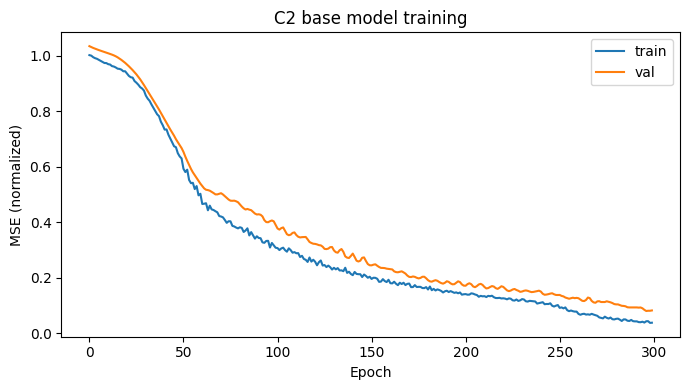

✓ Saved c2_training_curve.png


In [26]:
# CELL 19 — Training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE (normalized)')
plt.title('C2 base model training')
plt.legend()
plt.tight_layout()
plt.savefig(f'{save_dir}/c2_training_curve.png', dpi=150)
plt.show()
print('✓ Saved c2_training_curve.png')

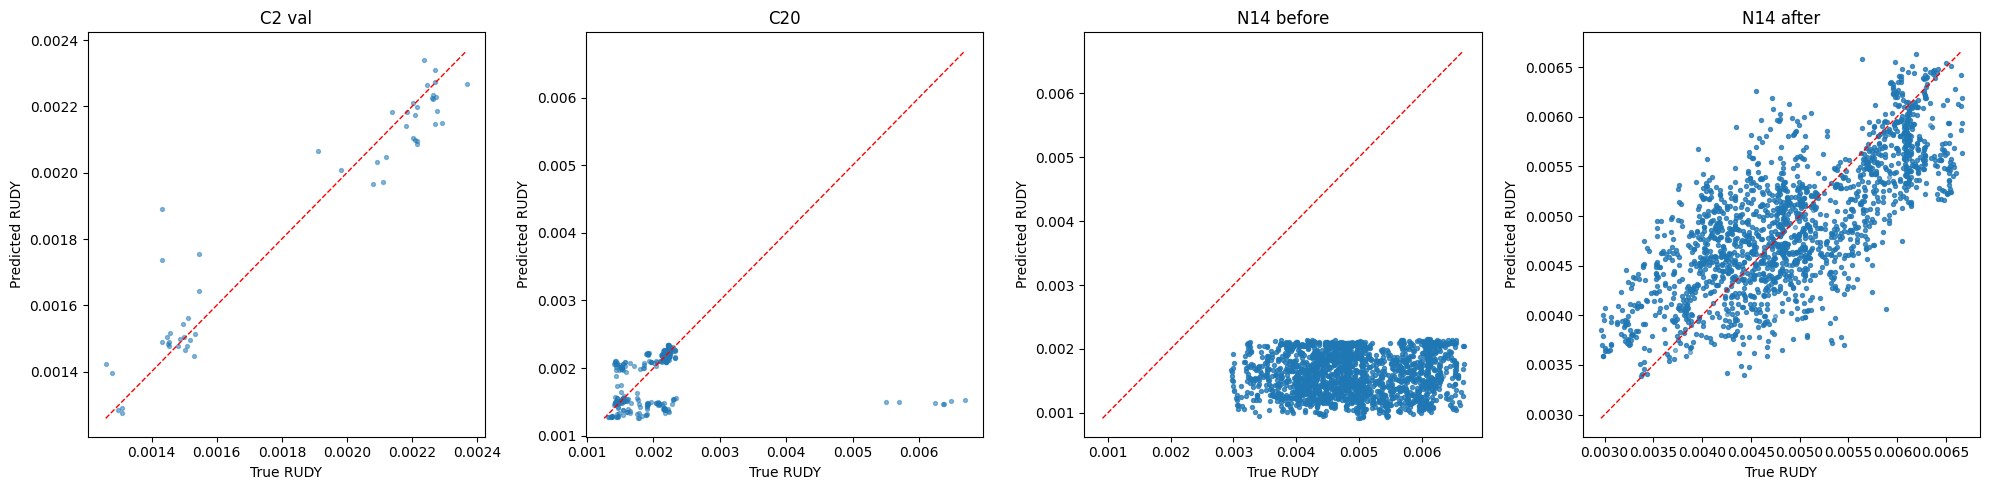

✓ Saved pred_vs_actual.png


In [27]:
# CELL 20 — Predicted vs actual scatter plots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
pairs = [
    ('C2 val',     base_c2_final_raw[val_idx.to(device)].cpu(), c2_true[val_idx].cpu()),
    ('C20',        base_c20_final_raw.cpu(),                    c20_true.cpu()),
    ('N14 before', base_n14_raw.cpu(),                          n14_true.cpu()),
    ('N14 after',  after_n14_raw.cpu(),                         n14_true.cpu()),
]
for ax, (name, pred, true) in zip(axes, pairs):
    ax.scatter(true, pred, s=8, alpha=0.5)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('True RUDY')
    ax.set_ylabel('Predicted RUDY')
    ax.set_title(name)
plt.tight_layout()
plt.savefig(f'{save_dir}/pred_vs_actual.png', dpi=150)
plt.show()
print('✓ Saved pred_vs_actual.png')

In [28]:
# CELL 21 — Ablation helper: full-model training on N14 (no adapters, nothing frozen)
def train_full_n14(net, base_x, edge_index, cfg_all, y_norm, train_idx, val_idx,
                    epochs=300, patience=40, lr=1e-3, tag='ablation'):
    """
    Trains EVERY parameter of `net` on N14 directly -- no PEDA adapters, nothing
    frozen. Used for two ablations:
      - starting from the C2-pretrained checkpoint -> 'full fine-tuning'
      - starting from a fresh random init           -> 'train from scratch'
    This is the comparison that tells us whether PEDA's parameter-efficiency
    is actually worth it, or whether just fine-tuning everything works just
    as well (or better).
    """
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=25)
    loss_fn_local = nn.MSELoss()

    base_x_d = base_x.to(device)
    edge_d = edge_index.to(device)
    train_cfg = cfg_all[train_idx].to(device)
    val_cfg = cfg_all[val_idx].to(device)
    train_y = y_norm[train_idx].to(device)
    val_y = y_norm[val_idx].to(device)

    best_val = float('inf')
    epochs_no_improve = 0
    ckpt_path = f'{save_dir}/{tag}_n14_best.pt'
    train_hist, val_hist = [], []

    for epoch in range(1, epochs + 1):
        net.train()
        optimizer.zero_grad(set_to_none=True)
        pred = net.predict_n14(base_x_d, edge_d, train_cfg)
        loss = loss_fn_local(pred, train_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=5.0)
        optimizer.step()

        net.eval()
        with torch.no_grad():
            val_pred = net.predict_n14(base_x_d, edge_d, val_cfg)
            val_loss = loss_fn_local(val_pred, val_y)
        val_value = val_loss.item()
        scheduler.step(val_value)

        train_hist.append(loss.item())
        val_hist.append(val_value)

        if val_value < best_val - 1e-10:
            best_val = val_value
            epochs_no_improve = 0
            torch.save(net.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1

        if epoch == 1 or epoch % 25 == 0:
            print(f'[{tag}] Epoch {epoch:3d} | train={loss.item():.6f} | val={val_value:.6f}')

        if epochs_no_improve >= patience:
            print(f'[{tag}] Early stopping at epoch {epoch}.')
            break

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    net.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    print(f'✓ [{tag}] best val loss: {best_val:.6f} | saved: {ckpt_path}')
    return net, train_hist, val_hist

In [29]:
# CELL 22 — Ablation A: full fine-tuning of the pretrained model on N14
finetune_model = ConfigConditionedGNN().to(device)
finetune_model.load_state_dict(
    torch.load(f'{save_dir}/base_gnn_config_conditioned.pt', map_location=device, weights_only=True)
)
# Unlike PEDA, nothing stays frozen here -- every parameter is trainable.
for p in finetune_model.parameters():
    p.requires_grad = True

finetune_model, ft_train_hist, ft_val_hist = train_full_n14(
    finetune_model, n14_base_x, n14_edge_index, n14_cfg, y_n14_norm_source,
    n14_train_idx, n14_val_idx, epochs=300, patience=40, tag='finetune'
)

with torch.no_grad():
    ft_pred_norm = finetune_model.predict_n14(
        n14_base_x.to(device), n14_edge_index.to(device), n14_cfg.to(device)
    )
ft_pred_raw = c2_norm_to_raw(ft_pred_norm)

print('\n=== Ablation A: Full fine-tuning on N14 ===')
print_metrics('N14 (full fine-tune)', metrics_raw(ft_pred_raw, n14_true))

[finetune] Epoch   1 | train=81.311844 | val=76.618874
[finetune] Epoch  25 | train=25.924107 | val=22.619411
[finetune] Epoch  50 | train=5.370908 | val=4.981910
[finetune] Epoch  75 | train=3.781060 | val=3.456259
[finetune] Epoch 100 | train=3.286359 | val=3.068500
[finetune] Epoch 125 | train=2.895966 | val=2.753173
[finetune] Epoch 150 | train=2.645577 | val=2.531348
[finetune] Epoch 175 | train=2.435888 | val=2.296231
[finetune] Epoch 200 | train=2.203426 | val=2.082141
[finetune] Epoch 225 | train=2.060715 | val=1.912026
[finetune] Epoch 250 | train=1.867001 | val=1.762330
[finetune] Epoch 275 | train=1.763759 | val=1.637568
[finetune] Epoch 300 | train=1.651878 | val=1.512397
✓ [finetune] best val loss: 1.512397 | saved: /content/drive/MyDrive/PEDA_Processed/finetune_n14_best.pt

=== Ablation A: Full fine-tuning on N14 ===
N14 (full fine-tune)         MSE=2.1001033e-07 | MAE=0.00035856964 | RMSE=0.00045826884 | Pearson=0.851662


In [30]:
# CELL 23 — Ablation B: train an identical architecture from scratch on N14 only
scratch_model = ConfigConditionedGNN().to(device)   # random init -- NO C2 pretraining at all
for p in scratch_model.parameters():
    p.requires_grad = True

scratch_model, sc_train_hist, sc_val_hist = train_full_n14(
    scratch_model, n14_base_x, n14_edge_index, n14_cfg, y_n14_norm_source,
    n14_train_idx, n14_val_idx, epochs=300, patience=40, tag='scratch'
)

with torch.no_grad():
    sc_pred_norm = scratch_model.predict_n14(
        n14_base_x.to(device), n14_edge_index.to(device), n14_cfg.to(device)
    )
sc_pred_raw = c2_norm_to_raw(sc_pred_norm)

print('\n=== Ablation B: Train from scratch on N14 (no C2 pretraining) ===')
print_metrics('N14 (from scratch)', metrics_raw(sc_pred_raw, n14_true))

[scratch] Epoch   1 | train=71.880348 | val=70.777763
[scratch] Epoch  25 | train=65.303909 | val=63.723312
[scratch] Epoch  50 | train=8.939385 | val=6.542779
[scratch] Epoch  75 | train=5.022733 | val=4.587754
[scratch] Epoch 100 | train=3.632041 | val=3.332142
[scratch] Epoch 125 | train=3.258827 | val=3.085999
[scratch] Epoch 150 | train=2.920172 | val=2.801708
[scratch] Epoch 175 | train=2.642659 | val=2.558006
[scratch] Epoch 200 | train=2.479791 | val=2.388064
[scratch] Epoch 225 | train=2.369334 | val=2.254114
[scratch] Epoch 250 | train=2.244526 | val=2.132018
[scratch] Epoch 275 | train=2.104317 | val=2.023547
[scratch] Epoch 300 | train=1.999988 | val=1.927992
✓ [scratch] best val loss: 1.927992 | saved: /content/drive/MyDrive/PEDA_Processed/scratch_n14_best.pt

=== Ablation B: Train from scratch on N14 (no C2 pretraining) ===
N14 (from scratch)           MSE=2.679439e-07 | MAE=0.00040815244 | RMSE=0.00051763298 | Pearson=0.805946


In [31]:
# CELL 24 — Ablation comparison: does PEDA's parameter-efficiency actually pay off?
ablation_rows = [
    ('N14', 'No adaptation (source only)',   metrics_raw(base_n14_raw, n14_true)),
    ('N14', 'PEDA (adapters only)',          metrics_raw(after_n14_raw, n14_true)),
    ('N14', 'Full fine-tuning',              metrics_raw(ft_pred_raw, n14_true)),
    ('N14', 'From scratch (no pretraining)', metrics_raw(sc_pred_raw, n14_true)),
]

peda_trainable = sum(p.numel() for p in peda_n14.parameters() if p.requires_grad)
peda_total = sum(p.numel() for p in peda_n14.parameters())
full_total = sum(p.numel() for p in finetune_model.parameters())

print('=== N14 Ablation: PEDA vs full fine-tuning vs from-scratch ===\n')
for domain, method, m in ablation_rows:
    print_metrics(f'{domain} | {method}', m)

print(f'\nPEDA trainable params : {peda_trainable:,} / {peda_total:,} ({100*peda_trainable/peda_total:.2f}%)')
print(f'Full fine-tune params : {full_total:,} / {full_total:,} (100.00%)')
print(f'From-scratch params   : {full_total:,} / {full_total:,} (100.00%, but no C2 pretraining)')

import pandas as pd
ablation_df = pd.DataFrame([
    {'domain': d, 'method': m, **metrics} for d, m, metrics in ablation_rows
])
ablation_df.to_csv(f'{save_dir}/n14_ablation_results.csv', index=False)
print(f'\n✓ Saved n14_ablation_results.csv')

=== N14 Ablation: PEDA vs full fine-tuning vs from-scratch ===

N14 | No adaptation (source only) MSE=1.1773116e-05 | MAE=0.0033051644 | RMSE=0.0034311975 | Pearson=0.038250
N14 | PEDA (adapters only)   MSE=3.663877e-07 | MAE=0.00049296056 | RMSE=0.00060529967 | Pearson=0.721971
N14 | Full fine-tuning       MSE=2.1001033e-07 | MAE=0.00035856964 | RMSE=0.00045826884 | Pearson=0.851662
N14 | From scratch (no pretraining) MSE=2.679439e-07 | MAE=0.00040815244 | RMSE=0.00051763298 | Pearson=0.805946

PEDA trainable params : 1,616 / 13,985 (11.56%)
Full fine-tune params : 13,089 / 13,089 (100.00%)
From-scratch params   : 13,089 / 13,089 (100.00%, but no C2 pretraining)

✓ Saved n14_ablation_results.csv


In [32]:
# CELL 25 — Final results summary table (for the report)
import pandas as pd

rows = [
    ('C2 validation', 'source (no adaptation)', metrics_raw(base_c2_final_raw[val_idx.to(device)], c2_true[val_idx])),
    ('C20',           'source (no adaptation)', metrics_raw(base_c20_final_raw, c20_true)),
    ('C20',           'PEDA adapters',          metrics_raw(pc20_raw, c20_true)),
    ('N14',           'source (no adaptation)', metrics_raw(base_n14_raw, n14_true)),
    ('N14',           'PEDA adapters',          metrics_raw(after_n14_raw, n14_true)),
    ('N14',           'full fine-tuning',       metrics_raw(ft_pred_raw, n14_true)),
    ('N14',           'from scratch',           metrics_raw(sc_pred_raw, n14_true)),
]

df = pd.DataFrame([{'domain': d, 'method': m, **metrics} for d, m, metrics in rows])
print(df.to_string(index=False))
df.to_csv(f'{save_dir}/final_results.csv', index=False)
print(f'\n✓ Saved final_results.csv')

       domain                 method          MSE      MAE     RMSE  Pearson
C2 validation source (no adaptation) 1.171613e-08 0.000074 0.000108 0.962323
          C20 source (no adaptation) 6.878421e-07 0.000351 0.000829 0.090054
          C20          PEDA adapters 4.566247e-07 0.000273 0.000676 0.513547
          N14 source (no adaptation) 1.177312e-05 0.003305 0.003431 0.038250
          N14          PEDA adapters 3.663877e-07 0.000493 0.000605 0.721971
          N14       full fine-tuning 2.100103e-07 0.000359 0.000458 0.851662
          N14           from scratch 2.679439e-07 0.000408 0.000518 0.805946

✓ Saved final_results.csv
